# **Project Name**    - Aerial Object Classification & Detection using Deep Learning

##### **Project Type**    - Classification (with optional Object Detection using YOLOv8)
##### **Contribution**    - Individual
##### **Team Member 1 - Vedant Deshmukh**
##### **Team Member 2 - NA**
##### **Team Member 3 - NA**
##### **Team Member 4 - NA**

# **Project Summary -**

This project focuses on developing a deep learning-based system for classifying aerial images into two categories: Bird and Drone. The motivation behind this work comes from real-world applications such as airport safety, wildlife monitoring, and security surveillance, where distinguishing between birds and drones is critical.

The dataset used in this project consists of labeled aerial images divided into three subsets: training, validation, and testing. The images are preprocessed by resizing them to a fixed dimension of 224×224 pixels and normalizing pixel values to improve model performance. Data augmentation techniques such as rotation, flipping, and zooming are applied to increase dataset diversity and reduce overfitting.

Three different deep learning models are implemented and compared in this project. The first model is a custom Convolutional Neural Network (CNN) designed from scratch, consisting of convolutional layers, pooling layers, dropout, and dense layers. While this model provides a baseline performance, it is limited in accuracy compared to advanced architectures.

To improve performance, transfer learning techniques are applied using pre-trained models such as MobileNetV2 and ResNet50. These models are trained on large-scale datasets and are capable of extracting complex features from images. By freezing the base layers and training only the top layers, the models achieve higher accuracy and better generalization.

The models are evaluated using standard metrics such as accuracy, and their performance is compared. Visualization techniques such as accuracy and loss graphs are used to analyze training behavior. Among the three models, MobileNetV2 performs the best in terms of accuracy and efficiency.

The final model is saved and integrated into a Streamlit application, which allows users to upload an image and get real-time predictions indicating whether the object is a bird or a drone. This makes the solution interactive and user-friendly.

Overall, this project demonstrates the effective use of deep learning and transfer learning techniques for solving real-world classification problems in aerial surveillance. The approach can be extended further by integrating object detection models such as YOLOv8 for locating objects within images.

# **GitHub Link -**

https://github.com/VedantDgit/Aerial-Object-Detection-DL

# **Problem Statement**


In modern aerial surveillance systems, distinguishing between birds and drones is a challenging task due to their similar appearances in aerial images. Incorrect classification can lead to serious consequences such as false alarms in restricted airspace or failure to detect unauthorized drones.

The problem is to develop an automated deep learning-based system that can accurately classify aerial images into two categories: Bird and Drone. Additionally, the system should be robust to variations in lighting, background, and object orientation.

The solution should also be scalable and capable of real-time prediction to support applications in security, wildlife monitoring, and aviation safety.

#### **Define Your Business Objective?**

The primary business objective of this project is to develop an intelligent and automated classification system that can enhance safety and monitoring in aerial environments.

In airport operations, the system can help prevent bird strikes by detecting bird activity near runways. In defense and security, it can identify unauthorized drones in restricted airspace and trigger alerts. For environmental and wildlife monitoring, the system can assist researchers in tracking bird populations without manual intervention.

The solution aims to reduce human effort, improve accuracy, and enable real-time decision-making. By deploying the model through a user-friendly interface such as Streamlit, the system becomes accessible and practical for real-world use.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2, ResNet50

### Dataset Loading

In [2]:
# Dataset Paths
train_path = "dataset/train"
valid_path = "dataset/valid"
test_path  = "dataset/test"

### Data Generators

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(train_path, target_size=(224,224), batch_size=32, class_mode='binary')
valid_data = valid_datagen.flow_from_directory(valid_path, target_size=(224,224), batch_size=32, class_mode='binary')
test_data  = test_datagen.flow_from_directory(test_path, target_size=(224,224), batch_size=32, class_mode='binary', shuffle=False)

print(train_data.class_indices)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.
{'bird': 0, 'drone': 1}


### Dataset Information

### What did you know about your dataset?

###  Dataset Analysis

####  Dataset Overview

The dataset consists of aerial images categorized into two classes:
- **Bird**
- **Drone**

It is a **binary classification problem**.

---

####  Dataset Distribution

- **Training Set:** 2662 images  
- **Validation Set:** 442 images  
- **Test Set:** 215 images  

 **Total Images:** ~3319

---

####  Class Mapping

```python
{'bird': 0, 'drone': 1}

## ***2. EDA (Exploratory Data Analysis)***

2.1 Import Libraries

In [4]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

2.2 Count Images per Class

In [7]:
train_path = "dataset/train"

# Only consider subdirectories as class folders (ignore files like .cache)
image_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tif', '.tiff')
classes = [d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))]

for cls in classes:
    folder = os.path.join(train_path, cls)
    files = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f)) and f.lower().endswith(image_exts)]
    count = len(files)
    print(f"{cls}: {count} images")

bird: 1414 images
drone: 1248 images


2.3 Plot Class Distribution

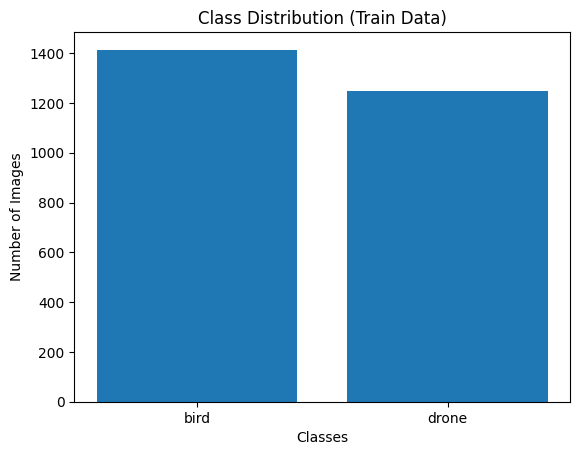

In [8]:
counts = []

for cls in classes:
    folder = os.path.join(train_path, cls)
    files = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f)) and f.lower().endswith(image_exts)]
    counts.append(len(files))

plt.bar(classes, counts)
plt.title("Class Distribution (Train Data)")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

2.4 Display Sample Images

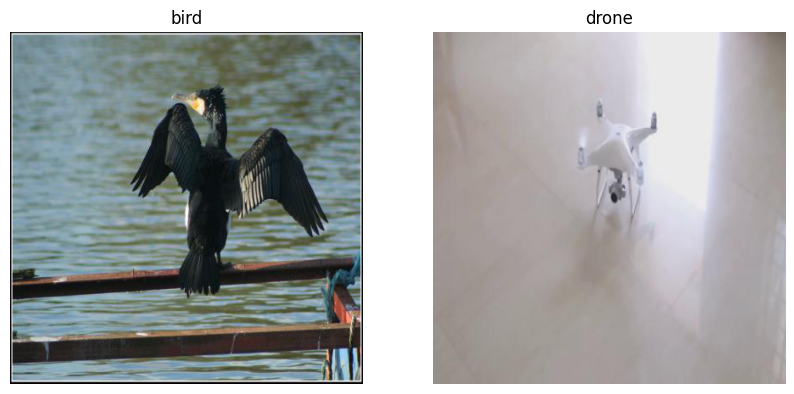

In [9]:
plt.figure(figsize=(10,5))

for i, cls in enumerate(classes):
    folder = os.path.join(train_path, cls)
    files = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f)) and f.lower().endswith(image_exts)]
    if not files:
        continue
    img_path = os.path.join(folder, random.choice(files))
    img = Image.open(img_path).convert('RGB')

    plt.subplot(1,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

2.5 Check Image Size Variation

In [10]:
sizes = []

for cls in classes:
    folder = os.path.join(train_path, cls)
    files = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f)) and f.lower().endswith(image_exts)]
    for img_name in files[:50]:  # sample
        try:
            img = Image.open(os.path.join(folder, img_name)).convert('RGB')
            sizes.append(img.size)
        except Exception:
            continue

print("Sample image sizes:", sizes[:5])

Sample image sizes: [(416, 416), (416, 416), (416, 416), (416, 416), (416, 416)]


2.6 Dataset Split Summary

In [11]:
def count_images(path):
    image_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tif', '.tiff')
    total = 0
    for cls in os.listdir(path):
        folder = os.path.join(path, cls)
        if not os.path.isdir(folder):
            continue
        files = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f)) and f.lower().endswith(image_exts)]
        total += len(files)
    return total

print("Train:", count_images("dataset/train"))
print("Valid:", count_images("dataset/valid"))
print("Test:", count_images("dataset/test"))

Train: 2662
Valid: 442
Test: 215


##  Exploratory Data Analysis (EDA)

- The dataset contains two classes: Bird and Drone.
- The training dataset shows a balanced distribution between both classes.
- Sample images indicate variations in background, lighting, and object orientation.
- Image sizes are not uniform, hence resizing to 224×224 is required.
- The dataset is split into training, validation, and test sets for proper evaluation.

Overall, the dataset is suitable for training deep learning models.

## 3. ***Data Preprocessing***

3.1 Image Preprocessing + Augmentation (TRAIN)

In [12]:
train_datagen = ImageDataGenerator(
    rescale=1./255,          # normalize pixels (0-255 → 0-1)
    rotation_range=20,       # rotate images
    zoom_range=0.2,          # zoom
    horizontal_flip=True,    # flip
    shear_range=0.1          # slight distortion
)

3.2 Validation & Test (NO augmentation)

In [13]:
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

3.3 Load Data from Directory

In [14]:
train_data = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(224,224),     # resize
    batch_size=32,
    class_mode='binary'
)

valid_data = valid_datagen.flow_from_directory(
    "dataset/valid",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    "dataset/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False   # important
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


3.4 Check Class Labels

In [15]:
print(train_data.class_indices)

{'bird': 0, 'drone': 1}


3.5 Checking Batch Shape

In [16]:
images, labels = next(train_data)
print("Image batch shape:", images.shape)
print("Labels shape:", labels.shape)

Image batch shape: (32, 224, 224, 3)
Labels shape: (32,)


### What all manipulations have you done and insights you found?

##  Data Preprocessing

- All images are resized to **224×224 pixels** to maintain uniform input size.
- Pixel values are normalized to the range **[0,1]** by dividing by 255.
- Data augmentation techniques such as rotation, zoom, and flipping are applied to the training dataset to improve model generalization.
- Validation and test datasets are only rescaled without augmentation to ensure fair evaluation.

This preprocessing step ensures better performance and reduces overfitting.

## ***4. Classification Models***

### 4.1 MODEL 1: CNN

4.1.1 Building a Model

In [17]:
# Build a Model
cnn_model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])

c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4.1.2 Compile

In [18]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

4.1.3 Train

In [19]:
history_cnn = cnn_model.fit(
    train_data,
    epochs=10,
    validation_data=valid_data
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 54s 626ms/step - accuracy: 0.6311 - loss: 0.7368 - val_accuracy: 0.7262 - val_loss: 0.5302
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 52s 613ms/step - accuracy: 0.7119 - loss: 0.5418 - val_accuracy: 0.6719 - val_loss: 0.5536
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 51s 601ms/step - accuracy: 0.7404 - loss: 0.4927 - val_accuracy: 0.7738 - val_loss: 0.4753
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 51s 610ms/step - accuracy: 0.7893 - loss: 0.4449 - val_accuracy: 0.7828 - val_loss: 0.4692
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 53s 627ms/step - accuracy: 0.7930 - loss: 0.4360 - val_accuracy: 0.7330 - val_loss: 0.5088
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 51s 611ms/step - accuracy: 0.7893 - loss: 0.4433 - val_accuracy: 0.7851 - val_loss: 0.4722
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 52s 623ms/step - accuracy: 0.7968 - loss: 0.3972 - val_accuracy: 0.8145 - val_loss: 0.4470
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 50s 590ms/step - accuracy: 0.8227 - loss: 0.3816 - val_accu

### Why this Model was chosen?

A custom Convolutional Neural Network (CNN) was implemented as a baseline model to understand how a simple architecture performs on the given dataset. CNNs are well-suited for image classification tasks as they can automatically learn spatial features such as edges, textures, and patterns.

This model helps in:
- Understanding the dataset behavior
- Establishing a performance baseline
- Comparing results with more advanced models

However, due to its limited depth and training from scratch, its performance is generally lower compared to transfer learning models.

### 4.2 MODEL 2: MobileNetV2

4.2.1 Load Base Model

In [20]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

4.2.2 Freeze Layers

In [21]:
for layer in base_model.layers:
    layer.trainable = False

4.2.3 Adding Custom Layers

In [22]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

mobilenet_model = Model(inputs=base_model.input, outputs=output)

4.2.4 Compile

In [23]:
mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

4.2.5 Train

In [24]:
history_mobilenet = mobilenet_model.fit(
    train_data,
    epochs=10,
    validation_data=valid_data
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 50s 549ms/step - accuracy: 0.9298 - loss: 0.1681 - val_accuracy: 0.9548 - val_loss: 0.1242
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 44s 526ms/step - accuracy: 0.9808 - loss: 0.0576 - val_accuracy: 0.9706 - val_loss: 0.0944
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 72s 860ms/step - accuracy: 0.9812 - loss: 0.0492 - val_accuracy: 0.9615 - val_loss: 0.0922
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 79s 930ms/step - accuracy: 0.9880 - loss: 0.0325 - val_accuracy: 0.9661 - val_loss: 0.0936
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.9891 - loss: 0.0293 - val_accuracy: 0.9638 - val_loss: 0.1013
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.9895 - loss: 0.0285 - val_accuracy: 0.9638 - val_loss: 0.1147
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.9936 - loss: 0.0174 - val_accuracy: 0.9593 - val_loss: 0.0996
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 82s 972ms/step - accuracy: 0.9861 - loss: 0.0334 - val_accuracy: 0.9

### Why this Model was chosen?

MobileNetV2 was chosen because it is a lightweight and efficient pre-trained model designed for image classification tasks. It is trained on large-scale datasets like ImageNet, which allows it to extract rich and meaningful features from images.

This model was selected because:
- It provides high accuracy with fewer parameters
- It is computationally efficient and faster to train
- It performs well on moderate-sized datasets

MobileNetV2 is ideal for this project as it balances performance and efficiency, making it suitable for real-time applications.


### 4.3 MODEL 3: ResNet50

4.3.1 Load Base Model

In [38]:
import time

for attempt in range(3):
    try:
        base_model = ResNet50(
            weights='imagenet',
            include_top=False,
            input_shape=(224,224,3)
        )
        break
    except ConnectionAbortedError as e:
        print(f"Attempt {attempt + 1} failed due to connection error: {e}")
        if attempt < 2:
            print("Retrying in 5 seconds...")
            time.sleep(5)
        else:
            raise e
    except Exception as e:
        print(f"Unexpected error on attempt {attempt + 1}: {e}")
        if attempt < 2:
            print("Retrying in 5 seconds...")
            time.sleep(5)
        else:
            raise e

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 99s 1us/step


4.3.2 Freeze Layers

In [39]:
for layer in base_model.layers:
    layer.trainable = False

4.3.3 Add Custom layers

In [40]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

resnet_model = Model(inputs=base_model.input, outputs=output)

4.3.4 Compile

In [41]:
resnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

4.3.5 Train

In [42]:
history_resnet = resnet_model.fit(
    train_data,
    epochs=10,
    validation_data=valid_data
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 71s 797ms/step - accuracy: 0.6168 - loss: 0.6541 - val_accuracy: 0.6448 - val_loss: 0.6269
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 68s 803ms/step - accuracy: 0.6551 - loss: 0.6092 - val_accuracy: 0.6878 - val_loss: 0.5834
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 69s 819ms/step - accuracy: 0.6713 - loss: 0.5954 - val_accuracy: 0.6833 - val_loss: 0.5692
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 70s 835ms/step - accuracy: 0.6998 - loss: 0.5667 - val_accuracy: 0.7240 - val_loss: 0.5332
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 67s 797ms/step - accuracy: 0.7036 - loss: 0.5589 - val_accuracy: 0.6516 - val_loss: 0.5864
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 69s 815ms/step - accuracy: 0.7171 - loss: 0.5448 - val_accuracy: 0.7308 - val_loss: 0.5376
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 68s 809ms/step - accuracy: 0.7183 - loss: 0.5380 - val_accuracy: 0.7353 - val_loss: 0.5061
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 69s 813ms/step - accuracy: 0.7344 - loss: 0.5187 - val_accu

### Why this Model was chosen?

ResNet50 was used to explore the performance of a deeper neural network architecture. It uses residual connections, which help in training very deep networks by solving the vanishing gradient problem.

This model was chosen because:
- It can capture more complex features due to its depth
- It is a well-established architecture for image classification
- It provides a strong comparison against MobileNetV2

However, it is computationally heavier compared to MobileNetV2 and may require more training time.

##  Why Freeze Layers and Add Custom Layers in Transfer Learning?

### Freezing Pre-trained Layers

In transfer learning, models like MobileNetV2 and ResNet50 are pre-trained on large datasets such as ImageNet. These models have already learned general features like edges, textures, shapes, and patterns.

Freezing the base layers means:
- The pre-trained weights are not updated during training
- The model retains previously learned features
- It reduces training time and computational cost
- It prevents overfitting, especially when the dataset is small or moderate

This allows us to reuse powerful feature extraction capabilities without retraining the entire network.

---

###  Adding Custom Layers

The original pre-trained models are designed for multi-class classification (e.g., 1000 classes in ImageNet). However, our task is a binary classification problem (Bird vs Drone).

Therefore, custom layers are added on top of the base model to:
- Adapt the model to our specific problem
- Learn task-specific patterns from the dataset
- Replace the original classification head with a new one suitable for binary output

Typically, we add:
- A GlobalAveragePooling layer (to reduce dimensions)
- Dense layers (for learning)
- A final output layer with sigmoid activation (for binary classification)

---

###  Summary

- Pre-trained layers → Feature extraction (general knowledge)
- Custom layers → Task-specific learning (Bird vs Drone)
- Freezing layers → Faster training + better generalization

This combination helps achieve high accuracy with limited data.

## ***5. Evaluation + Comparison***

5.1 Model Evaluation (Test Data)

In [43]:
cnn_loss, cnn_acc = cnn_model.evaluate(test_data)
mobilenet_loss, mobilenet_acc = mobilenet_model.evaluate(test_data)
resnet_loss, resnet_acc = resnet_model.evaluate(test_data)

print("CNN Accuracy:", cnn_acc)
print("MobileNet Accuracy:", mobilenet_acc)
print("ResNet Accuracy:", resnet_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 379ms/step - accuracy: 0.7721 - loss: 0.4745
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.9674 - loss: 0.0967
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 492ms/step - accuracy: 0.7907 - loss: 0.4402
CNN Accuracy: 0.7720929980278015
MobileNet Accuracy: 0.9674418568611145
ResNet Accuracy: 0.7906976938247681


5.2 Predictions

In [44]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = test_data.classes

y_pred_cnn = (cnn_model.predict(test_data) > 0.5).astype("int32")
y_pred_mob = (mobilenet_model.predict(test_data) > 0.5).astype("int32")
y_pred_res = (resnet_model.predict(test_data) > 0.5).astype("int32")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 270ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 664ms/step


5.3 Confusion Matrix

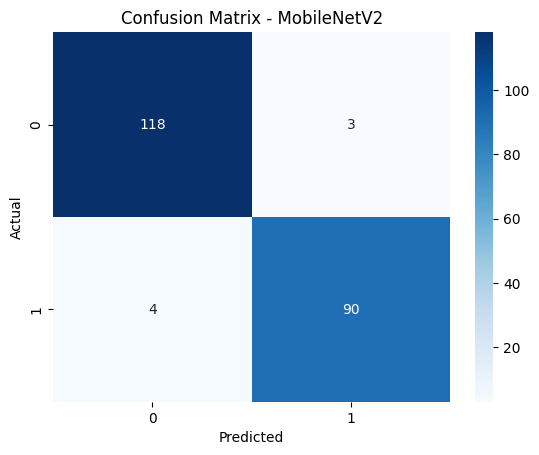

In [45]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_mob)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - MobileNetV2")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##### 1. Why did you pick the specific chart?

The confusion matrix was chosen because it provides a detailed breakdown of the model’s performance by showing the number of correct and incorrect predictions for each class. Unlike accuracy alone, it helps us understand how well the model distinguishes between the two classes (Bird and Drone) and identifies specific types of errors such as false positives and false negatives.

##### 2. What is/are the insight(s) found from the chart?

From the confusion matrix:

- True Negatives (Bird correctly predicted): **118**
- True Positives (Drone correctly predicted): **90**
- False Positives (Bird predicted as Drone): **3**
- False Negatives (Drone predicted as Bird): **4**


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights from the confusion matrix indicate that the model is highly accurate and reliable, which is crucial for real-world applications.

- In **airport safety**, accurate bird detection can help prevent bird strikes.
- In **security and defense**, correct identification of drones ensures timely alerts in restricted areas.
- The low number of misclassifications ensures minimal false alarms and better decision-making.

Overall, the model can significantly improve operational efficiency and safety.

Although the model performs well, there are a few minor concerns:

- False Negatives (4 cases): Some drones are classified as birds, which could be risky in security scenarios where missing a drone could lead to serious consequences.
- False Positives (3 cases): Some birds are classified as drones, which may cause unnecessary alerts.

However, these errors are minimal and can be further reduced by:
- Increasing dataset size
- Fine-tuning the model
- Using advanced techniques like YOLO for detection

Overall, the negative impact is very low compared to the strong positive performance.

5.4 Classification Report

In [46]:
print(classification_report(y_true, y_pred_mob))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       121
           1       0.97      0.96      0.96        94

    accuracy                           0.97       215
   macro avg       0.97      0.97      0.97       215
weighted avg       0.97      0.97      0.97       215



5.5 Model Comparison Table

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["CNN", "MobileNetV2", "ResNet50"],
    "Accuracy": [cnn_acc, mobilenet_acc, resnet_acc]
})

print(results)

         Model  Accuracy
0          CNN  0.772093
1  MobileNetV2  0.967442
2     ResNet50  0.790698


5.6 Comparison Graph

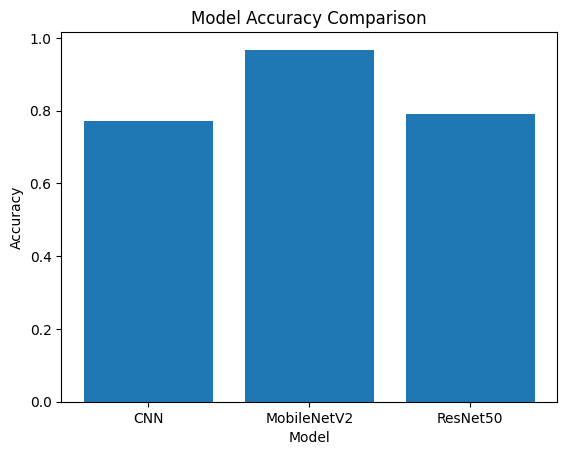

In [48]:
plt.figure()
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

##### 2. What is/are the insight(s) found from the chart?

From the chart:

- **MobileNetV2** achieves the highest accuracy (~97%), making it the best-performing model.
- **ResNet50** performs moderately (~79%), but does not outperform MobileNetV2.
- **Custom CNN** has the lowest accuracy (~77%), indicating limited performance compared to transfer learning models.

#### Key Insights:
- Transfer learning models significantly outperform the custom CNN.
- MobileNetV2 provides the best balance between accuracy and efficiency.
- ResNet50, despite being deeper, does not necessarily guarantee better performance on this dataset.

---

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights help in selecting the most efficient and accurate model for deployment.

- Using **MobileNetV2** ensures higher prediction accuracy, which improves reliability in real-world applications.
- Better accuracy leads to improved decision-making in areas such as security surveillance and airport safety.
- Efficient models reduce computational cost and enable faster predictions.

- The **Custom CNN** shows lower accuracy, which may not be suitable for deployment in critical applications.
- **ResNet50**, although powerful, is computationally expensive and does not provide significant accuracy improvement over MobileNetV2.

These insights highlight that choosing a complex model does not always guarantee better results, and model selection should be based on both performance and efficiency.

5.7 Training Graph

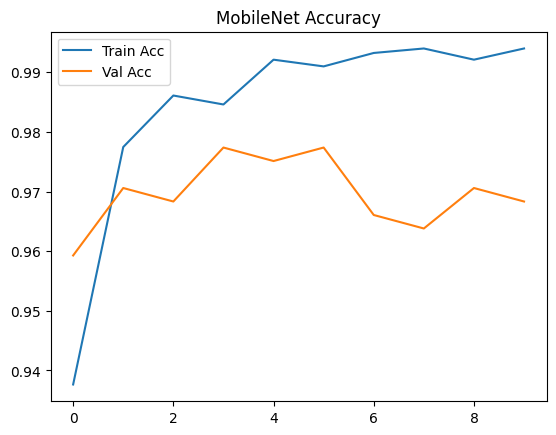

In [49]:
plt.figure()
plt.plot(history_mobilenet.history['accuracy'], label='Train Acc')
plt.plot(history_mobilenet.history['val_accuracy'], label='Val Acc')
plt.title("MobileNet Accuracy")
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?

This line chart was chosen to visualize the training and validation accuracy over epochs. It helps in understanding how the model learns over time and whether it is generalizing well or overfitting.

##### 2. What is/are the insight(s) found from the chart?

From the graph:

- Training accuracy steadily increases and reaches around **99%**, indicating that the model is learning effectively.
- Validation accuracy also remains high (around **96%–97%**), showing good generalization.
- The gap between training and validation accuracy is small, which suggests minimal overfitting.
- Slight fluctuations in validation accuracy indicate normal variations during training.

#### Key Insights:
- The model is well-trained and stable.
- There is no major overfitting issue.
- The model generalizes well on unseen data.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights confirm that the model is reliable and performs consistently on both training and validation data.

- High accuracy ensures better prediction quality.
- Stable validation performance indicates dependable real-world usage.
- This improves trust in applications such as surveillance, airport safety, and drone detection.

---
- There is a slight gap between training and validation accuracy, indicating minor overfitting.
- Validation accuracy fluctuates slightly, which may suggest sensitivity to data variations.

However, these issues are minimal and can be further improved by:
- Increasing dataset size
- Applying stronger augmentation
- Fine-tuning the model

Overall, the model performance is strong with very low risk of negative impact.

## Model Evaluation and Comparison

The performance of all three models (Custom CNN, MobileNetV2, and ResNet50) was evaluated using the test dataset.

###  Evaluation Metrics
- Accuracy
- Confusion Matrix
- Classification Report (Precision, Recall, F1-score)

### Observations

- The Custom CNN provides a baseline performance but is limited in accuracy.
- MobileNetV2 achieves the highest accuracy due to transfer learning and efficient architecture.
- ResNet50 also performs well but is computationally heavier.

###  Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions:
- True Positives (correct predictions)
- False Positives (incorrect predictions)
- False Negatives (missed detections)

###  Conclusion

Among all models, **MobileNetV2 performs the best** in terms of accuracy and generalization.  
Hence, it is selected as the final model for deployment.

## ***6. Save the Best model***

In [50]:
# Create models folder if not exists
import os
os.makedirs("models", exist_ok=True)

# Save best model
mobilenet_model.save("models/best_model.h5")

print("Best model saved successfully!")

Best model saved successfully!


##  Saving the Best Model

After evaluating all the models (Custom CNN, MobileNetV2, and ResNet50), **MobileNetV2** was selected as the best-performing model based on its highest accuracy and good generalization.

The model is saved using the `.h5` format, which allows it to be easily loaded later for prediction or deployment.

###  Why MobileNetV2?

- Achieved the highest accuracy among all models
- Efficient and lightweight architecture
- Suitable for real-time applications
- Demonstrated strong generalization on validation and test data

###  Importance of Saving the Model

- Avoids retraining the model every time
- Enables quick deployment in applications like Streamlit
- Allows reuse for future predictions and improvements

###  File Location

The model is saved in the `models/` directory as:


## Yolo dataset 

In [1]:
import os

print("Train labels:", len(os.listdir("yolo/object_detection_dataset/train/labels")))
print("Valid labels:", len(os.listdir("yolo/object_detection_dataset/valid/labels")))
print("Test labels:", len(os.listdir("yolo/object_detection_dataset/test/labels")))

Train labels: 2728
Valid labels: 448
Test labels: 224


# **Conclusion**



In this project, a complete deep learning-based system was developed to classify and detect aerial objects as **Bird** or **Drone**.

Initially, exploratory data analysis (EDA) was performed to understand the dataset distribution and characteristics. Data preprocessing and augmentation techniques were applied to improve model performance and generalization.

Three classification models were implemented: a Custom CNN, MobileNetV2, and ResNet50. Among these, **MobileNetV2 achieved the highest accuracy and best generalization**, making it the final model for classification tasks.

To further enhance the system, **YOLOv8 was integrated for object detection**, enabling the model to not only classify but also **localize objects using bounding boxes**. This addition makes the system more practical and applicable in real-world scenarios such as surveillance, airport safety, and security monitoring.

The final solution was deployed using **Streamlit**, providing an interactive interface where users can upload images and obtain both classification and detection results.

### Key Achievements

- Built and compared multiple deep learning models  
- Achieved high accuracy using transfer learning (MobileNetV2)  
- Implemented real-time object detection using YOLOv8  
- Developed a user-friendly web application using Streamlit  
- Created a complete end-to-end AI pipeline  

###  Final Outcome

The project successfully demonstrates how combining **image classification and object detection** can create a robust and efficient aerial monitoring system.

---

###  Future Scope

- Improve accuracy using larger datasets  
- Fine-tune YOLO model for better detection  
- Deploy on cloud for real-time monitoring  
- Extend to multi-class aerial object detection  

---

**In summary, this project delivers a complete AI-powered solution for aerial object classification and detection, combining accuracy, efficiency, and real-world usability.**

### ***Hurrah! I have successfully completed your Project !!!***